Python Notebook for NER evaluation based on Lables Studio conll styled output.

## Data and Libraries

In [ ]:
import nervaluate as nv
import json
import pandas as pd
import seaborn as sns

## Preprocessing

### Simulating Predictions as Annotations to export them in CONLL format

In [ ]:
def save_annotations_and_predictions(json_data, annotations_filename, predictions_filename):
    annotations_list = []
    predictions_list = []

    for item in json_data:
        # --- Extract human annotations ---
        if "annotations" in item and item["annotations"]:
            human_annot = item.copy()
            human_annot["predictions"] = []  # Strip predictions if present
            annotations_list.append(human_annot)

        # --- Extract predictions from inside annotation -> prediction -> result ---
        if "annotations" in item and item["annotations"]:
            inner_annot = item["annotations"][0]
            if "prediction" in inner_annot and "result" in inner_annot["prediction"]:
                pred_results = inner_annot["prediction"]["result"]

                pred_item = item.copy()
                pred_item["annotations"] = [{
                    "id": None,
                    "completed_by": None,
                    "result": [
                        {**r, "origin": "prediction"} for r in pred_results
                    ],
                    "was_cancelled": False,
                    "ground_truth": False,
                    "created_at": None,
                    "updated_at": None,
                    "lead_time": None
                }]
                predictions_list.append(pred_item)

    with open(annotations_filename, 'w') as f_out:
        json.dump(annotations_list, f_out, indent=4)

    with open(predictions_filename, 'w') as f_out:
        json.dump(predictions_list, f_out, indent=4)


In [ ]:
# Load the original JSON data
file_path = "DATA/LABEL_STUDIO/project-6-at-2025-10-02-07-01-dccafd13.json"
save_path = "DATA/LABEL_STUDIO/NER_EVAL/"

with open(file_path, 'r') as f:
    data = json.load(f)

an_save_path = save_path + "an_" + file_path.split("/")[-1]
pr_save_path = save_path + "pr_" + file_path.split("/")[-1]

# Save annotations and predictions as separate files
save_annotations_and_predictions(data, an_save_path, pr_save_path)

print("Files saved successfully!")


Next, resulting files are loaded into a new Label Studio Project where they can be exported manually in the desirec CONLL format.

This results in:

``` shell
an_project-6-at-2025-04-09-17-56-c855702b.conll
an_project-6-at-2025-04-09-17-56-c855702b.json
pr_project-6-at-2025-04-09-17-56-c855702b.conll
pr_project-6-at-2025-04-09-17-56-c855702b.json

```

Note that it is also possible to compare annotated results predictions from another model (i.e. another run of the same model). This is done by importing the predictions to the Label Studio first, an then exporting it in classic json and running the first two cells of this script for a new file again. For this, first use [gliner_restults2labelstudio](gliner_results2labelstudio.ipynb) notebook.

> Warning: This takes some data mingeling, you need to make annotations from predictions via label studio interface and then export the portion that is truely human annotated.

Sentence example:

```
-DOCSTART- -X- O
The -X- _ O
marine -X- _ B-Chemical
algal -X- _ I-Chemical
toxin -X- _ I-Chemical
domoic -X- _ B-Chemical
acid -X- _ I-Chemical
is -X- _ O
an -X- _ O
.
.
.
```

Input example:

``` python

true = "word\tO\nword\tO\B-PER\nword\tI-PER\n"

pred = "word\tO\nword\tO\B-PER\nword\tI-PER\n"

evaluator = Evaluator(true, pred, tags=['PER'], loader="conll")

results, results_by_tag, result_indices, result_indices_by_tag = evaluator.evaluate()

```

We need to adjust the CONLL format a little:

In [ ]:
# Input and output file paths

import re


input_file = "DATA/LABEL_STUDIO/NER_EVAL/pr_project-6-at-2025-10-02-07-03-dccafd13.conll"
output_file = "DATA/LABEL_STUDIO/NER_EVAL/fixed_pr_project-6-at-2025-10-02-07-03-dccafd13.conll"

with open(input_file, "r") as f:
    input = f.readlines()

print(input)

output = [re.sub(r" -X- (_ ){0,1}", "\\t", i) for i in input]
print(output)

with open(output_file, "x") as f:
    f.writelines(output)

## Evaluation

In [ ]:
anot_path = "DATA/LABEL_STUDIO/NER_EVAL/fixed_an_project-6-at-2025-10-02-07-03-dccafd13.conll"
pred_path = "DATA/LABEL_STUDIO/NER_EVAL/fixed_pr_project-6-at-2025-10-02-07-03-dccafd13.conll"

with open(anot_path, "r") as f:
    anot = f.read()

with open(pred_path, "r") as f:
    pred = f.read()

In [ ]:
FET = """Ecosystem
Energy Source
Natural Disaster
Meteorological Phenomenon
Quantity
Astronomical Object
Body of Water
Disease
Location
Physical Phenomenon
Chemical
Time Period
Organization
Natural Phenomenon
Field of Study
Mathematical Expression
Measuring Device
Geographical Feature
System
Satellite
Organism
Method
Other
Person
Artefact
Body Part
Symptom"""

labels = FET.split("\n")

In [ ]:
from nervaluate import Evaluator
evaluator = Evaluator(anot, pred, tags=labels, loader="conll") # one example .split("\n\n")[1]

results, results_by_tag, result_indices, result_indices_by_tag = evaluator.evaluate()


In [ ]:
import pandas as pd

df = pd.DataFrame(results)
print(df)

In [ ]:
print("\n##results##:\n")
print("Strict: ", results["strict"])
print("Exact:  ", results["exact"])
print("\##results_by_tag##:\n")
print(results_by_tag)
print("\##result_indices##:\n")
print(result_indices)
print("\##result_indices_by_tag##:\n")
print(result_indices_by_tag)


## Visuals for Evaluation

### Overall Metrics (Strict, Partial, Exact, Ent-Type) — Bar Chart

In [ ]:
import matplotlib.pyplot as plt

def plot_overall_metrics(results):
    metrics = ['strict', 'exact', 'ent_type', 'partial']
    precision = [results[m]['precision'] for m in metrics]
    recall = [results[m]['recall'] for m in metrics]
    f1 = [results[m]['f1'] for m in metrics]

    x = range(len(metrics))
    width = 0.25

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar([i - width for i in x], precision, width, label='Precision')
    ax.bar(x, recall, width, label='Recall')
    ax.bar([i + width for i in x], f1, width, label='F1 Score')

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylabel("Score")
    ax.set_title("Overall NER Evaluation Scores")
    ax.set_ylim(0, 1.1)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_overall_metrics(results)

### Per-Entity-Type F1 Score — Bar Chart (from results_by_tag)

In [ ]:
def plot_f1_per_entity(results_by_tag, scheme='strict'):
    labels = list(results_by_tag.keys())
    print(labels)
    f1_scores = [results_by_tag[label][scheme]['f1'] for label in labels]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(labels, f1_scores, color='#09bdfe')
    ax.set_ylabel("F1 Score")
    ax.set_title(f"F1 Score per Entity Type ({scheme} match)")
    ax.set_ylim(0, 1)

    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
for scheme in ['strict', 'partial', 'exact', 'ent_type']:
    plot_f1_per_entity(results_by_tag, scheme)

### Per entity type F1 score overlay

In [ ]:
import numpy as np
def plot_f1_dual_shading_per_entity(results_by_tag):
    labels = list(results_by_tag.keys())
    exact_f1 = [results_by_tag[label]['exact']['f1'] for label in labels]
    strict_f1 = [results_by_tag[label]['strict']['f1'] for label in labels]

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(labels))

    # Yellow base bars for 'exact'
    bars_exact = ax.bar(labels, exact_f1, color='#09bdfe', label='Exact')

    # Overlay semi-transparent green bars for 'strict'
    bars_strict = ax.bar(labels, strict_f1, color='#90ee90', alpha=0.5, label='Strict')

    ax.set_ylabel("F1 Score")
    ax.set_title("F1 Score per Entity Type (Exact vs Strict)")
    ax.set_ylim(0, 1)

    for i, label in enumerate(labels):
        strict_val = strict_f1[i]
        exact_val = exact_f1[i]

        # Annotate strict score
        ax.annotate(f'+{exact_val-strict_val:.2f}', xy=(x[i], exact_val), xytext=(0, 3),
                    textcoords="offset points", ha='center', va='bottom', fontsize=7)

        # Annotate exact score only if different
        # if strict_val != exact_val:
        #     ax.annotate(f'{exact_val:.2f}', xy=(x[i], exact_val), xytext=(0, 12),
        #                 textcoords="offset points", ha='center', va='bottom')

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.legend()
    plt.show()

# Usage
plot_f1_dual_shading_per_entity(results_by_tag)


### Per entity type F1 scopre diff

In [ ]:

def plot_f1_difference_unsorted(results_by_tag):
    """
    Calculates and plots the difference between 'exact' and 'strict' F1 scores
    for each entity type, maintaining the original order of the labels.

    This visualization highlights which entity types are most affected by
    type misclassification errors. A large bar means the model is good at
    finding the entity's boundaries but poor at assigning the correct label.
    
    Args:
        results_by_tag (dict): The dictionary containing evaluation results,
                               structured by entity tag.
    """
    # Get labels in their original order from the results dictionary
    labels = list(results_by_tag.keys())
    
    # Calculate the F1 score difference (Exact - Strict) for each entity
    performance_diffs = []
    for label in labels:
        metrics = results_by_tag[label]
        # Ensure keys exist to avoid errors; default to 0 if not found
        f1_exact = metrics.get('exact', {}).get('f1', 0)
        f1_strict = metrics.get('strict', {}).get('f1', 0)
        performance_diffs.append(f1_exact - f1_strict)

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(labels, performance_diffs, color='lightcoral')

    ax.set_ylabel("F1 Score Drop (Exact - Strict)")
    ax.set_title("Performance Drop Due to Type Misclassification per Entity")
    ax.set_ylim(0, max(performance_diffs) * 1.15 if performance_diffs else 1) # Dynamic Y-axis

    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

    plt.xticks(rotation=45, ha="right") # Rotate labels for better readability
    plt.tight_layout() # Adjust plot to ensure everything fits without overlapping
    plt.show()
    
plot_f1_difference_unsorted(results_by_tag)

### Radar Chart for Comparing F1 Scores Across Match Schemes

In [ ]:
from math import pi
import matplotlib.pyplot as plt

def radar_comparison(results_by_tag, entity_label):
    schemes = ['strict', 'partial', 'exact', 'ent_type']
    f1_scores = [results_by_tag[entity_label][s]['f1'] for s in schemes]

    f1_scores += f1_scores[:1]  # close the circle
    angles = [n / float(len(schemes)) * 2 * pi for n in range(len(f1_scores))]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, f1_scores, linewidth=1, linestyle='solid')
    ax.fill(angles, f1_scores, alpha=0.3)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(schemes)
    ax.set_title(f"Match Type Comparison for '{entity_label}'", size=14)
    ax.set_ylim(0, 1)
    plt.show()

for label in results_by_tag.keys():
    radar_comparison(results_by_tag, label)

###  Entity Frequency vs. F1 Score Scatterplot

In [ ]:
def plot_freq_vs_f1(results_by_tag, scheme='strict'):
    import seaborn as sns

    labels = []
    freq = []
    f1 = []

    for tag, metrics in results_by_tag.items():
        labels.append(tag)
        freq.append(metrics[scheme]['possible'])
        f1.append(metrics[scheme]['f1'])

    df = pd.DataFrame({'Label': labels, 'Frequency': freq, 'F1': f1})

    plt.figure(figsize=(16, 12))
    sns.scatterplot(data=df, x="Frequency", y="F1", hue="Label", s=100, palette="Set2")
    for i in range(len(df)):
        plt.text(df.Frequency[i], df.F1[i], df.Label[i])
    plt.title(f"Entity Frequency vs F1 ({scheme})")
    plt.xlabel("Frequency in Dataset")
    plt.ylabel("F1 Score")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

for scheme in ['strict', 'partial', 'exact', 'ent_type']:
    plot_freq_vs_f1(results_by_tag, scheme)

### Frequency vs F1 combined

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def plot_freq_vs_f1_combined_fixed(results_by_tag):
    # (The data preparation part is identical to the previous version)
    data_for_df = []
    for tag, metrics in results_by_tag.items():
        frequency = metrics.get('strict', {}).get('possible', 0)
        f1_strict = metrics.get('strict', {}).get('f1', 0)
        f1_exact = metrics.get('exact', {}).get('f1', 0)
        data_for_df.append({'Label': tag, 'Frequency': frequency, 'F1': f1_strict, 'Scheme': 'Strict'})
        data_for_df.append({'Label': tag, 'Frequency': frequency, 'F1': f1_exact, 'Scheme': 'Exact'})
    
    df = pd.DataFrame(data_for_df)
    # Filter out zero-frequency points to avoid issues with log scale
    df = df[df['Frequency'] > 0].copy()

    # --- Plotting ---
    plt.figure(figsize=(16, 12))

    # 1. Draw connecting lines
    for label in df['Label'].unique():
        label_data = df[df['Label'] == label]
        plt.plot(label_data['Frequency'], label_data['F1'], 
                 color='grey', linestyle='--', linewidth=0.5, zorder=1)

    # 2. Draw scatter plot
    sns.scatterplot(data=df, x="Frequency", y="F1", hue="Scheme", style="Scheme", s=150, zorder=2)
    
    # 3. Add text labels
    for i in range(len(df)):
        if df.iloc[i]['Scheme'] == 'Exact':
            plt.text(df.iloc[i]['Frequency'] * 1.02, df.iloc[i]['F1'], df.iloc[i]['Label'], fontsize=9)
            
    # Manually set the x-axis limits to contain the data points
    min_freq = df['Frequency'].min()
    max_freq = df['Frequency'].max()
    plt.xlim(min_freq * 0.9, max_freq * 1.1)
    
    # --- NEW: Add reference lines ---
    plt.axvline(x=100, color='crimson', linestyle=':', lw=0.5)#, label='Freq=100')
    plt.axhline(y=results["strict"]["f1"], color='crimson', linestyle=':', lw=0.5)#, label=f'F1={results["strict"]["f1"]:.2f}')
    # Define the intersection point and axis boundaries
    intersect_x, intersect_y = 100, results["strict"]["f1"]
    _, x_max_limit = plt.xlim()
    _, y_max_limit = plt.ylim()

    # Draw the vertical line segment (from intersection up)
    plt.plot([intersect_x, intersect_x], [intersect_y, y_max_limit], 
             color='crimson', linestyle=':', lw=2, 
             label=f'Thresholds (Freq=100, F1={results["strict"]["f1"]:.2f})') # Add a single label for the legend

    # Draw the horizontal line segment (from intersection right)
    plt.plot([intersect_x, x_max_limit], [intersect_y, intersect_y], 
             color='crimson', linestyle=':', lw=2)
    # --------------------------------
            
    plt.title("Entity Frequency vs F1 Score (Exact vs. Strict)")
    plt.xlabel("Frequency in Dataset (Number of True Entities)")
    plt.ylabel("F1 Score")
    plt.ylim(-0.05, 1.05)
    plt.xscale('log') 
    
    # --- REMOVED: The plt.grid() line has been deleted ---
    
    plt.legend(title='Evaluation Scheme')
    
    plt.tight_layout()
    plt.show()

# Example usage:
# plot_freq_vs_f1_combined_fixed(results_by_tag)

# Example usage:
# plot_freq_vs_f1_combined_fixed(results_by_tag)
    
plot_freq_vs_f1_combined_fixed(results_by_tag)

### Confusion matrix

**Interpreting the Heatmap:**
- **Main Diagonal:** Shows **Correct Predictions** where the model's predicted label matches the true label. Higher numbers here are better.
- **Off-Diagonal Cells:** Pinpoint **Type Confusion Errors**. Each cell shows how many times a true entity (row) was mislabeled as a different predicted entity (column)ll.
- **MISSED Column (False Negatives):** Counts the true entities of each type that the model completely failed to detect. This indicates a problem with model recall/sensitivity.
- **SPURIOUS Row (False Positives):** Counts the entities the model predicted that did not exist in the true data. This indicates a problem with model precision.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from nervaluate import Evaluator

# --- 1. Your Data Loading and Setup ---

anot_path = "DATA/LABEL_STUDIO/NER_EVAL/fixed_an_project-6-at-2025-10-02-07-03-dccafd13.conll"
pred_path = "DATA/LABEL_STUDIO/NER_EVAL/fixed_pr_project-6-at-2025-10-02-07-03-dccafd13.conll"

with open(anot_path, "r", encoding="utf-8") as f:
    anot = f.read()

with open(pred_path, "r", encoding="utf-8") as f:
    pred = f.read()

FET = """Ecosystem
Energy Source
Natural Disaster
Meteorological Phenomenon
Quantity
Astronomical Object
Body of Water
Disease
Location
Physical Phenomenon
Chemical
Time Period
Organization
Natural Phenomenon
Field of Study
Mathematical Expression
Measuring Device
Geographical Feature
System
Satellite
Organism
Method
Other
Person
Artefact
Body Part
Symptom"""

labels = FET.split("\n")

# --- 2. Confusion Matrix Generation Functions (CORRECTED) ---

def generate_confusion_matrix(evaluator: Evaluator) -> pd.DataFrame:
    """
    Generates a confusion matrix for NER evaluation.
    This version is corrected to use dictionary access e['label'] instead of e.label.
    """
    all_tags = set(evaluator.tags)
    for doc in evaluator.true:
        # Use dictionary access ['label']
        all_tags.update(e['label'] for e in doc)
    for doc in evaluator.pred:
        # Use dictionary access ['label']
        all_tags.update(e['label'] for e in doc)
    
    sorted_tags = sorted(list(set(evaluator.tags).intersection(all_tags)))

    matrix = pd.DataFrame(0,
                          index=sorted_tags + ['SPURIOUS'],
                          columns=sorted_tags + ['MISSED'])

    for true_doc, pred_doc in zip(evaluator.true, evaluator.pred):
        matched_true_indices = set()
        matched_pred_indices = set()

        for i, true_entity in enumerate(true_doc):
            if true_entity['label'] not in sorted_tags:
                continue
            for j, pred_entity in enumerate(pred_doc):
                if pred_entity['label'] not in sorted_tags:
                    continue
                if j in matched_pred_indices:
                    continue
                
                # Check for any overlap using dictionary access
                if pred_entity['start'] <= true_entity['end'] and pred_entity['end'] >= true_entity['start']:
                    # Use dictionary access for labels
                    matrix.loc[true_entity['label'], pred_entity['label']] += 1
                    matched_true_indices.add(i)
                    matched_pred_indices.add(j)
                    break 

        for i, true_entity in enumerate(true_doc):
            if true_entity['label'] in sorted_tags and i not in matched_true_indices:
                matrix.loc[true_entity['label'], 'MISSED'] += 1
        
        for j, pred_entity in enumerate(pred_doc):
            if pred_entity['label'] in sorted_tags and j not in matched_pred_indices:
                matrix.loc['SPURIOUS', pred_entity['label']] += 1
                
    return matrix


def plot_confusion_matrix(cm: pd.DataFrame, figsize: tuple = (20, 16)):
    """
    Plots the confusion matrix using a seaborn heatmap.
    """
    if cm.empty:
        print("Cannot plot an empty confusion matrix.")
        return
        
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=True, linewidths=.5)
    plt.title('NER Confusion Matrix', fontsize=20)
    plt.ylabel('True Label', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# --- 3. Initialize Evaluator and Perform Analysis ---
evaluator = Evaluator(anot, pred, tags=labels, loader="conll")

# The evaluate method has been updated in nervaluate.
# It now correctly returns a single dictionary.
evaluation_results = evaluator.evaluate()

# --- 4. Generate and Plot the Confusion Matrix ---
print("Generating confusion matrix...")
confusion_matrix_df = generate_confusion_matrix(evaluator)

print("\n--- NER Confusion Matrix (Raw Data) ---")
print(confusion_matrix_df)

print("\nPlotting confusion matrix heatmap...")
plot_confusion_matrix(confusion_matrix_df)

### Confusion Matrix normalized

**Interpreting the Heatmap:**
- **Main Diagonal:** This is now the **Recall** for each class (a value from 0.0 to 1.0). A value of 0.90 on the diagonal for Person means your model correctly identifies 90% of all true Person entities.
- **Off-Diagonal Cells:** This shows the proportion of a true class that was mislabeled. If the cell at (True: Person, Predicted: Organism) is 0.05, it means 5% of all true Person entities were incorrectly labeled as Organism.    
- **MISSED Column:** This shows the proportion of a true class that was missed. If the (True: Person, MISSED) cell is 0.05, it means 5% of all true Person entities were not detected at all.
- **Row Sum:** Each row (except for SPURIOUS) will add up to **1.0**. This represents 100% of the true entities for that class and how they were distributed across correct, incorrect, and missed predictions.
- **SPURIOUS Row:** This row is also normalized by its own sum, showing the distribution of predicted labels among all spurious entities. For example, if the (SPURIOUS, Location) cell is 0.40, it means that 40% of all spurious predictions were for the Location type.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from nervaluate import Evaluator

# --- 1. Your Data Loading and Setup (Unchanged) ---

anot_path = "DATA/LABEL_STUDIO/NER_EVAL/fixed_an_project-6-at-2025-10-02-07-03-dccafd13.conll"
pred_path = "DATA/LABEL_STUDIO/NER_EVAL/fixed_pr_project-6-at-2025-10-02-07-03-dccafd13.conll"

with open(anot_path, "r", encoding="utf-8") as f:
    anot = f.read()

with open(pred_path, "r", encoding="utf-8") as f:
    pred = f.read()

FET = """Ecosystem
Energy Source
Natural Disaster
Meteorological Phenomenon
Quantity
Astronomical Object
Body of Water
Disease
Location
Physical Phenomenon
Chemical
Time Period
Organization
Natural Phenomenon
Field of Study
Mathematical Expression
Measuring Device
Geographical Feature
System
Satellite
Organism
Method
Other
Person
Artefact
Body Part
Symptom"""

labels = FET.split("\n")

# --- 2. Confusion Matrix Generation Functions (Unchanged) ---

def generate_confusion_matrix(evaluator: Evaluator) -> pd.DataFrame:
    """
    Generates a confusion matrix for NER evaluation.
    """
    all_tags = set(evaluator.tags)
    for doc in evaluator.true:
        all_tags.update(e['label'] for e in doc)
    for doc in evaluator.pred:
        all_tags.update(e['label'] for e in doc)
    
    sorted_tags = sorted(list(set(evaluator.tags).intersection(all_tags)))

    matrix = pd.DataFrame(0,
                          index=sorted_tags + ['SPURIOUS'],
                          columns=sorted_tags + ['MISSED'])

    for true_doc, pred_doc in zip(evaluator.true, evaluator.pred):
        matched_true_indices = set()
        matched_pred_indices = set()

        for i, true_entity in enumerate(true_doc):
            if true_entity['label'] not in sorted_tags:
                continue
            for j, pred_entity in enumerate(pred_doc):
                if pred_entity['label'] not in sorted_tags:
                    continue
                if j in matched_pred_indices:
                    continue
                
                if pred_entity['start'] <= true_entity['end'] and pred_entity['end'] >= true_entity['start']:
                    matrix.loc[true_entity['label'], pred_entity['label']] += 1
                    matched_true_indices.add(i)
                    matched_pred_indices.add(j)
                    break 

        for i, true_entity in enumerate(true_doc):
            if true_entity['label'] in sorted_tags and i not in matched_true_indices:
                matrix.loc[true_entity['label'], 'MISSED'] += 1
        
        for j, pred_entity in enumerate(pred_doc):
            if pred_entity['label'] in sorted_tags and j not in matched_pred_indices:
                matrix.loc['SPURIOUS', pred_entity['label']] += 1
                
    return matrix


def plot_normalized_confusion_matrix(cm: pd.DataFrame, figsize: tuple = (20, 16)):
    """
    Normalizes the confusion matrix by the true label (row-wise) and plots it.
    This shows recall and the distribution of errors for each class.
    """
    if cm.empty:
        print("Cannot plot an empty confusion matrix.")
        return

    # Calculate row sums to normalize. This is the total number of true entities for each class.
    row_sums = cm.sum(axis=1)
    
    # Avoid division by zero for classes that have no instances
    row_sums[row_sums == 0] = 1 
    
    # Normalize the matrix row-wise
    cm_normalized = cm.div(row_sums, axis=0)

    plt.figure(figsize=figsize)
    # Use '.2f' format for floating point numbers and a different colormap to distinguish
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Oranges', cbar=True, linewidths=.5)
    plt.title('Normalized NER Confusion Matrix (Recall & Error Distribution)', fontsize=20)
    plt.ylabel('True Label', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# --- 3. Initialize Evaluator and Perform Analysis (Unchanged) ---
evaluator = Evaluator(anot, pred, tags=labels, loader="conll")
evaluation_results = evaluator.evaluate()

# --- 4. Generate and Plot Both Confusion Matrices ---
print("Generating confusion matrix...")
confusion_matrix_df = generate_confusion_matrix(evaluator)

# Plot the original, absolute-count matrix
print("\n--- NER Confusion Matrix (Raw Data) ---")
print(confusion_matrix_df)

# Plot the new, normalized matrix
print("\nPlotting normalized confusion matrix heatmap...")
plot_normalized_confusion_matrix(confusion_matrix_df)

## Analyisis on Labeling Results

In [45]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import random

from dataset_processing import *


import warnings # To suppress some warnings
 
# Suppress the specific FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

In [46]:
anot_path_json = "DATA/LABEL_STUDIO/LS_BIODIVNER/project-34-at-2025-12-08-13-44-2171ef2d.json"
# BioDivNER "DATA/LABEL_STUDIO/LS_BIODIVNER/project-34-at-2025-12-08-13-44-2171ef2d.json"
# ClimateIE "DATA/LABEL_STUDIO/LS_CLIMATEIE/project-35-at-2025-12-05-07-53-b0139f8e.json"
# Climate Change NER (IBM) "DATA/LABEL_STUDIO/LS_IBMCCNER/project-36-at-2025-12-08-13-43-e4ba28f1.json"
# "DATA/LABEL_STUDIO/project-30-at-2025-11-14-12-19-2a7464a5.json"
# "DATA/LABEL_STUDIO/LS_CLIMATEIE/project-35-at-2025-12-05-07-53-b0139f8e.json"
# "DATA/LABEL_STUDIO/LS_CLIMATEIE/project-35-at-2025-12-05-07-53-b0139f8e.json"
# "DATA/LABEL_STUDIO/project-30-at-2025-11-14-12-19-2a7464a5.json"
# "DATA/LABEL_STUDIO/LS_CLIMATEIE/project-35-at-2025-12-04-11-10-f9949a53.json"

### Type occurance vs unique examples

Analyzing Label Studio annotation data...

--- Annotation Data Analysis ---
                 EntityType  TotalCount  UniqueCount  DiversityRatio
0                     Asset           8            4        0.500000
1                 Body Part           2            2        1.000000
2             Body of Water           8            2        0.250000
3                  Chemical          50           10        0.200000
4                 Ecosystem          11            5        0.454545
5             Energy Source           3            3        1.000000
6      Geographical Feature           5            4        0.800000
7     Intellectual Artefact           4            4        1.000000
8                  Location          78           27        0.346154
9   Mathematical Expression           1            1        1.000000
10                   Method          22            7        0.318182
11         Natural Disaster           3            1        0.333333
12                 Organism

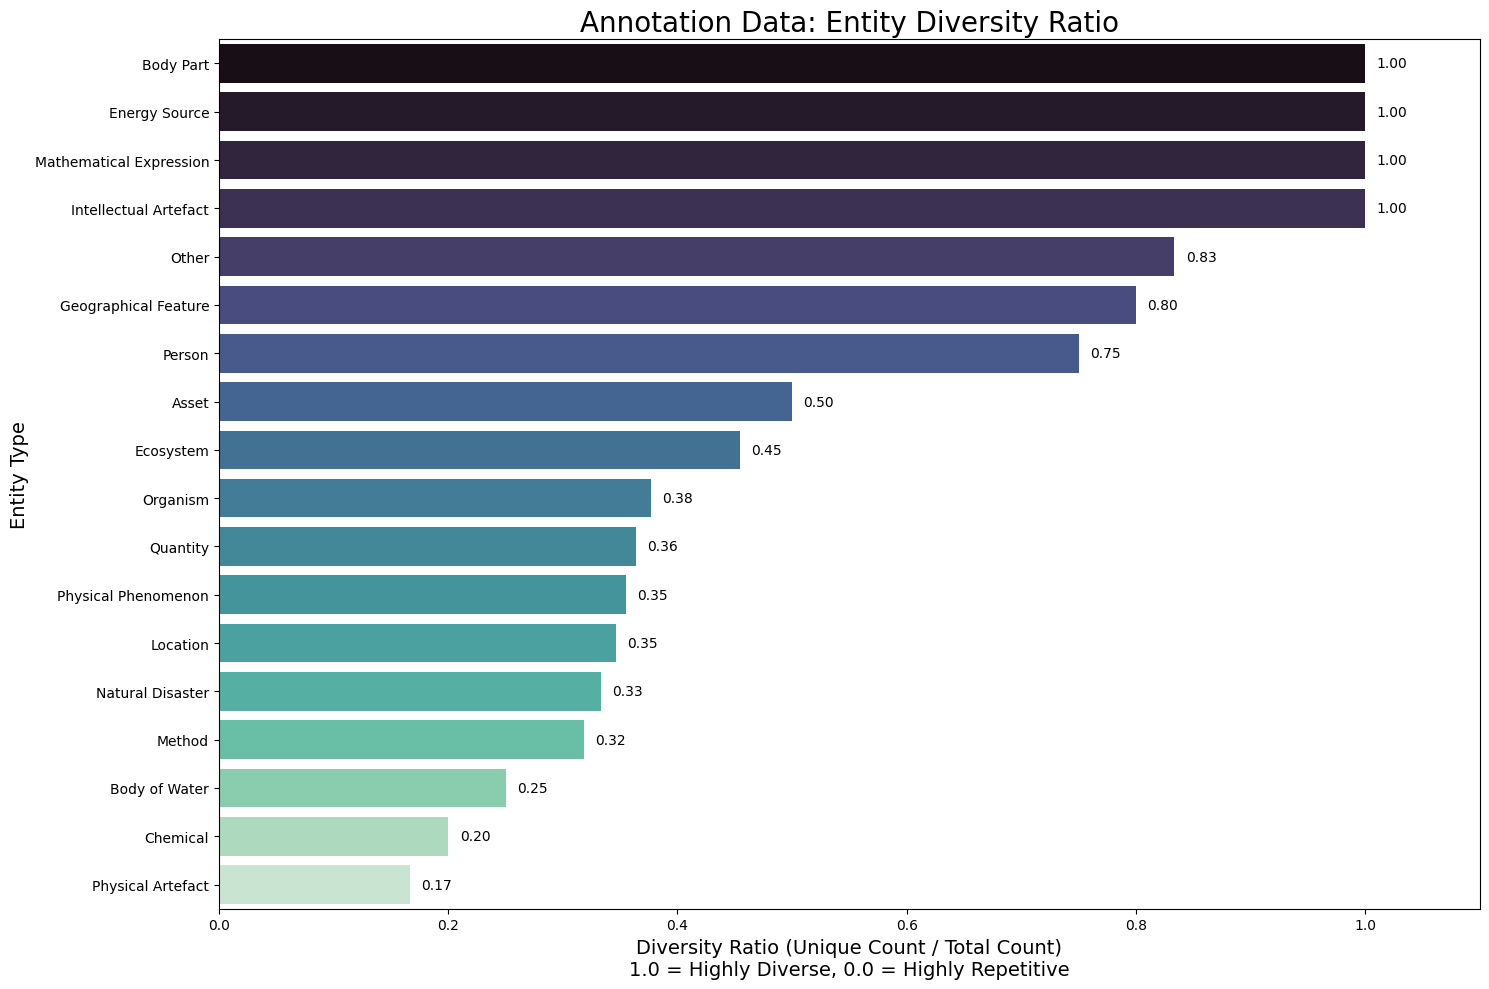

In [47]:
# --- 2. Function to Parse Label Studio JSON and Analyze Data ---


def plot_diversity_ratio(df: pd.DataFrame, figsize: tuple = (15, 10)):
    """
    Plots the entity diversity ratio in a sorted bar chart.
    """
    if df.empty:
        print("Cannot plot with empty data.")
        return
    
    # Sort by the ratio for a more meaningful plot
    df_sorted = df.sort_values('DiversityRatio', ascending=False)
    
    plt.figure(figsize=figsize)
    # Use a different palette for variety
    ax = sns.barplot(data=df_sorted, x='DiversityRatio', y='EntityType', palette='mako', legend=False, hue='EntityType',)
    
    ax.set_title('Annotation Data: Entity Diversity Ratio', fontsize=20)
    ax.set_xlabel('Diversity Ratio (Unique Count / Total Count)\n1.0 = Highly Diverse, 0.0 = Highly Repetitive', fontsize=14)
    ax.set_ylabel('Entity Type', fontsize=14)
    ax.set_xlim(0, 1.1)  # Give space for annotations

    # Annotate bars with the ratio value
    for p in ax.patches:
        width = p.get_width()
        plt.text(width + 0.01, p.get_y() + p.get_height() / 2.,
                 f'{width:.2f}',
                 va='center')

    plt.tight_layout()
    plt.show()

# --- 3. Run the Analysis and Plotting ---

print("Analyzing Label Studio annotation data...")
annotation_df, _ = analyze_annotation_data(anot_path_json)

# Print the resulting DataFrame to see all the numbers
print("\n--- Annotation Data Analysis ---")
# Use to_string() to ensure all rows are printed
print(annotation_df.to_string())

# Plot the diversity ratio
print("\nPlotting entity diversity ratio...")
plot_diversity_ratio(annotation_df)

### Type occurance vs unique examples via a scatter plot

Please install adjustText for better plots: pip install adjustText
Analyzing Label Studio annotation data...

Plotting diversity scatter plot...


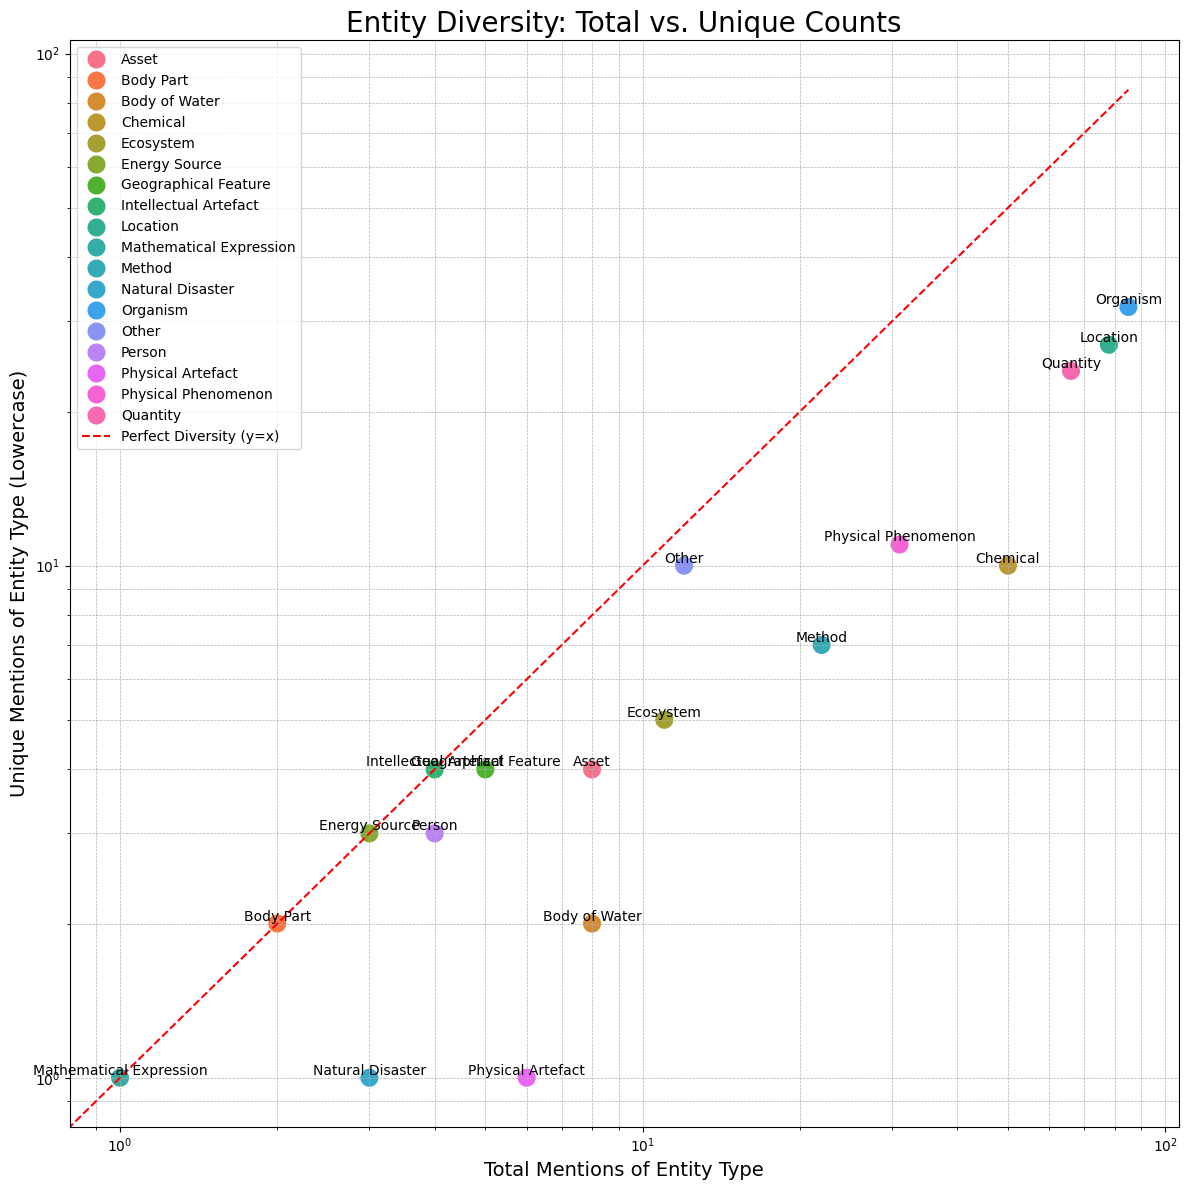


--- Top 5 'Heavy Hitters' per Entity Type ---

EntityType: Asset (Total Mentions: 8)
                      Count % of Total
freshwater                3      37.5%
arable land               2      25.0%
freshwater resources      2      25.0%
agricultural land         1      12.5%

Top 5 entities account for 100.00% of all 'Asset' mentions.

EntityType: Body Part (Total Mentions: 2)
                        Count % of Total
extrafloral nectaries       1      50.0%
soil fungal metagenome      1      50.0%

Top 5 entities account for 100.00% of all 'Body Part' mentions.

EntityType: Body of Water (Total Mentions: 8)
                     Count % of Total
water                    4      50.0%
elwha river estuary      4      50.0%

Top 5 entities account for 100.00% of all 'Body of Water' mentions.

EntityType: Chemical (Total Mentions: 50)
            Count % of Total
carbon         12      24.0%
nitrogen       10      20.0%
kcl             8      16.0%
h2o             6      12.0%
freshwate

In [48]:

def plot_diversity_scatterplot(df: pd.DataFrame, figsize: tuple = (12, 12)):
    """
    Generates a 2D scatter plot of Total vs. Unique entity counts.
    """
    if df.empty:
        print("Cannot plot with empty data.")
        return

    plt.figure(figsize=figsize)
    ax = sns.scatterplot(data=df, x='TotalCount', y='UniqueCount', hue='EntityType', s=200, legend='full')
    
    # Plot the y=x line for reference (perfect diversity)
    max_val = max(df['TotalCount'].max(), df['UniqueCount'].max())
    ax.plot([0, max_val], [0, max_val], 'r--', label='Perfect Diversity (y=x)')

    # Use adjust_text to prevent labels from overlapping
    texts = [plt.text(row.TotalCount, row.UniqueCount, row.EntityType) for i, row in df.iterrows()]
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    ax.set_title('Entity Diversity: Total vs. Unique Counts', fontsize=20)
    ax.set_xlabel('Total Mentions of Entity Type', fontsize=14)
    ax.set_ylabel('Unique Mentions of Entity Type (Lowercase)', fontsize=14)
    plt.xscale('log') # Use log scale if counts vary widely
    plt.yscale('log') # Use log scale if counts vary widely
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

def generate_top_n_report(all_entity_texts: dict, top_n: int = 5):
    """
    Generates and prints a report of the most frequent entities for each type.
    """
    print(f"\n--- Top {top_n} 'Heavy Hitters' per Entity Type ---\n")
    
    for entity_type, texts in sorted(all_entity_texts.items()):
        if not texts:
            continue
        
        # Count frequencies of each unique text
        counts = pd.Series(texts).value_counts()
        total_mentions = len(texts)

        print("="*60)
        print(f"EntityType: {entity_type} (Total Mentions: {total_mentions})")
        print("="*60)
        
        # Get the top N entities
        top_entities = counts.head(top_n)
        
        # Create a report DataFrame
        report_df = pd.DataFrame({
            'Count': top_entities,
            '% of Total': (top_entities / total_mentions * 100).round(2).astype(str) + '%'
        })
        
        print(report_df)
        
        # Calculate the percentage covered by the top N
        top_n_coverage = top_entities.sum() / total_mentions * 100
        print(f"\nTop {top_n} entities account for {top_n_coverage:.2f}% of all '{entity_type}' mentions.\n")

# --- 4. Run the Analysis and Plotting ---

# Make sure you have adjustText installed: pip install adjustText
try:
    from adjustText import adjust_text
except ImportError:
    print("Please install adjustText for better plots: pip install adjustText")
    # A fallback text function if adjustText is not available
    def adjust_text(texts, **kwargs):
        for text in texts:
            text.set_ha('center')
            text.set_va('bottom')

print("Analyzing Label Studio annotation data...")
# Unpack the two return values from the updated analysis function
annotation_df, all_texts = analyze_annotation_data(anot_path_json)

# --- Plot the Diversity Scatter Plot ---
print("\nPlotting diversity scatter plot...")
plot_diversity_scatterplot(annotation_df)

# --- Generate the Top-N Report ---
generate_top_n_report(all_texts, top_n=5)

### Per-entity type sample with the sentence

In [ ]:

def sample_entity_contexts(file_path: str, entity_type: str, n_samples: int = 5):
    """
    Parses a Label Studio JSON export and prints N random samples of a given
    entity type, along with the sentences in which they appear.

    Args:
        file_path: The path to the Label Studio JSON export file.
        entity_type: The entity label to sample (e.g., 'PERSON', 'ORG').
        n_samples: The number of random samples to retrieve.
    """
    found_entities = []

    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # Go through each annotated task
    for task in data:
        if not task.get('annotations'):
            continue
        
        # Get the sentence text, assuming it's in a 'text' field
        # Adjust 'text' if your Label Studio setup uses a different key
        sentence = task.get('data', {}).get('sentence', 'Sentence not found')
        
        annotations = task['annotations'][0]['result']
        
        # Find all occurrences of the desired entity type in this sentence
        for annotation in annotations:
            if annotation.get('type') != 'labels':
                continue
            
            value = annotation.get('value', {})
            if 'text' in value and 'labels' in value and value['labels']:
                label = value['labels'][0]
                text = value['text']
                
                if label == entity_type:
                    found_entities.append({'text': text, 'sentence': sentence})


    if not found_entities:
        print("No entities of this type were found.")
        return

    # Take a random sample
    # If n_samples is larger than found, it will just return all found entities
    num_to_sample = min(n_samples, len(found_entities))
    sampled_items = random.sample(found_entities, num_to_sample)
    
    print(f"Showing {num_to_sample} random samples of \"{TARGET_ENTITY_TYPE}\":")
    for i, item in enumerate(sampled_items, 1):
        print(f"{i}:")
        print(f"Sentence: \"{item['sentence']}\"")
        print(f"Entity: '{item['text']}'")
        

TARGET_ENTITY_TYPE = 'Intellectual Artefact' 
NUMBER_OF_SAMPLES = 1000

sample_entity_contexts(
    file_path=anot_path_json, 
    entity_type=TARGET_ENTITY_TYPE, 
    n_samples=NUMBER_OF_SAMPLES
)


### Entity search in annotations

In [44]:
from thefuzz import fuzz # Import the fuzzy matching library

def search_annotations_for_term_ranked(file_path: str, 
                                       search_term: str, 
                                       min_similarity_score: int = 60):
    """
    Searches annotations for a term with relevance ranking for different match types.

    Match Types & Ranking:
    1.  Exact Match (Score: 101): Perfect match.
    2.  Case-Insensitive Match (Score: 100): Matches after converting both to lowercase.
    3.  Contains (Score: 99): The search term is found within the annotated entity text.
    4.  Similar (Fuzzy Match, Score: 0-95): Based on Levenshtein distance, for typos, 
        plural variations, etc. The score is the similarity ratio.

    Args:
        file_path: Path to the Label Studio JSON export file.
        search_term: The text to search for within the annotations.
        min_similarity_score: The minimum score required for a 'Similar' match to be included.
    """
    found_occurrences = []

    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    normalized_search_term = search_term.lower()

    for task in data:
        if not task.get('annotations'):
            continue
        
        sentence = task.get('data', {}).get('sentence', 'Sentence not found')
        annotations = task['annotations'][0]['result']

        for annotation in annotations:
            if annotation.get('type') != 'labels':
                continue

            value = annotation.get('value', {})
            if 'text' in value and 'labels' in value and value['labels']:
                entity_text = value['text']
                entity_label = value['labels'][0]
                normalized_entity_text = entity_text.lower()
                
                score = 0
                match_type = ""

                # 1. Check for Exact Match (Highest Priority)
                if entity_text == search_term:
                    score = 101
                    match_type = "Exact"
                
                # 2. Check for Case-Insensitive Match
                elif normalized_entity_text == normalized_search_term:
                    score = 100
                    match_type = "Case-Insensitive"
                
                # 3. Check if search term is a substring of the entity
                elif normalized_search_term in normalized_entity_text:
                    score = 99
                    match_type = "Contains"
                
                # 4. Calculate Fuzzy Similarity Score
                else:
                    similarity_ratio = fuzz.ratio(normalized_search_term, normalized_entity_text)
                    if similarity_ratio >= min_similarity_score:
                        # We scale it down slightly to keep it below other match types
                        score = similarity_ratio * 0.95 
                        match_type = "Similar"

                # If a match was found, add it to our list
                if match_type:
                    found_occurrences.append({
                        'text': entity_text,
                        'label': entity_label,
                        'sentence': sentence,
                        'score': score,
                        'match_type': match_type
                    })

    # --- Sort the results by score in descending order ---
    sorted_occurrences = sorted(found_occurrences, key=lambda x: x['score'], reverse=True)

    # --- Print the results ---
    print(f"\n--- Searching for annotations related to the term '{search_term}' ---")
    if not sorted_occurrences:
        print("No relevant annotated entities found.")
        return

    print(f"Found {len(sorted_occurrences)} relevant occurrences:")
    for i, item in enumerate(sorted_occurrences, 1):
        print(f"\n{i}. Match Type: '{item['match_type']}' (Score: {item['score']:.2f})")
        print(f"   - Labeled as: '{item['label']}'")
        print(f"   - Original Text: '{item['text']}'")
        print(f"   - Sentence: \"{item['sentence']}\"")

search_term = "air pollution"
search_annotations_for_term_ranked(
    file_path=anot_path_json, 
    search_term=search_term,
)


--- Searching for annotations related to the term 'air pollution' ---
Found 71 relevant occurrences:

1. Match Type: 'Contains' (Score: 99.00)
   - Labeled as: 'Quantity'
   - Original Text: 'Air Pollution Tolerance Index'
   - Sentence: "The goal of the current study was to assess the Air Pollution Tolerance Index (APTI) and heavy metal absorption (Pb, Cd, Zn, and Ni) potential by ten selected trees planted along the roadside in the metropolitan city of Lahore, Pakistan."

2. Match Type: 'Contains' (Score: 99.00)
   - Labeled as: 'Quantity'
   - Original Text: 'air pollution tolerance index'
   - Sentence: "The air pollution tolerance index (APTI) of plant species was evaluated with the help of analysis of some biochemical parameters, and used to measure the heavy-metals accumulation capacity in their leaves and their levels of tolerance in a polluted environment."

3. Match Type: 'Contains' (Score: 99.00)
   - Labeled as: 'Natural Disaster'
   - Original Text: 'seasonal air pollutio

### Parsing of NER Labelling Directives

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# The graph data parsed from your final directives file.
# An edge from A to B means A's negative criteria redirects to B.
decision_graph_data = {
  "Artefact": [
    "Chemical", "Geographical Feature", "Measuring Device", "Method", 
    "Organism", "Organization", "Other", "Satellite"
  ],
  "Astronomical Object": [
    "Body of Water", "Energy Source", "Geographical Feature", "Location", 
    "Natural Phenomenon", "Other", "Satellite", "System"
  ],
  "Body of Water": ["Ecosystem", "Geographical Feature", "Meteorological Phenomenon"],
  "Body Part": ["Artefact", "Ecosystem", "Organism", "Other"],
  "Chemical": [
    "Artefact", "Body Part", "Disease", "Energy Source", "Method", 
    "Natural Phenomenon", "Organism", "Physical Phenomenon"
  ],
  "Disease": ["Body Part", "Chemical", "Measuring Device", "Method", "Organism"],
  "Ecosystem": ["Body of Water", "Geographical Feature", "Location", "Organism"],
  "Energy Source": ["Artefact", "Measuring Device", "Other", "Quantity", "System"],
  "Field of Study": ["Artefact", "Method", "Meteorological Phenomenon", "Other", "Person", "Quantity"],
  "Geographical Feature": ["Astronomical Object", "Body of Water", "Ecosystem", "Location"],
  "Location": ["Astronomical Object", "Body of Water", "Ecosystem", "Geographical Feature"],
  "Mathematical Expression": ["Artefact", "Method", "Other", "Quantity"],
  "Measuring Device": ["Artefact", "Method", "Quantity"],
  "Meteorological Phenomenon": ["Artefact", "Chemical", "Location", "Natural Disaster", "System"],
  "Method": [
    "Artefact", "Chemical", "Ecosystem", "Field of Study", "Measuring Device", 
    "Natural Phenomenon", "Organism", "Person"
  ],
  "Natural Disaster": ["Chemical", "Disease", "Geographical Feature", "Natural Phenomenon", "System"],
  "Natural Phenomenon": ["Chemical", "Method", "Meteorological Phenomenon", "Natural Disaster", "System"],
  "Organism": ["Body Part", "Chemical", "Ecosystem", "Method"],
  "Organization": ["Location", "Other", "Person"],
  "Other": ["Artefact", "Disease", "Ecosystem", "Method", "Person", "Quantity"],
  "Person": ["Method", "Organism", "Organization", "Other", "Physical Phenomenon"],
  "Physical Phenomenon": ["Chemical", "Meteorological Phenomenon", "Natural Disaster", "Natural Phenomenon", "Quantity"],
  "Quantity": ["Chemical", "Measuring Device", "Method", "Meteorological Phenomenon", "Physical Phenomenon", "Time Period"],
  "Satellite": ["Artefact", "Astronomical Object", "Measuring Device", "Method", "Organization"],
  "System": ["Artefact", "Ecosystem", "Geographical Feature", "Natural Phenomenon", "Physical Phenomenon"],
  "Time Period": ["Method", "Meteorological Phenomenon", "Physical Phenomenon", "Quantity"]
}

# --- Create and Plot the Graph ---

def create_and_plot_graph(graph_data):
    """
    Creates a NetworkX DiGraph from the dictionary and plots it.
    """
    # 1. Create a directed graph
    G = nx.DiGraph()

    # 2. Add nodes and edges from the data dictionary
    all_nodes = set(graph_data.keys())
    for targets in graph_data.values():
        all_nodes.update(targets)
    
    G.add_nodes_from(sorted(list(all_nodes)))

    for source, targets in graph_data.items():
        for target in targets:
            G.add_edge(source, target)

    # 3. Set up the plot
    plt.figure(figsize=(22, 22))
    
    # Use a layout algorithm that spreads nodes to minimize overlap.
    # The 'k' parameter adjusts the optimal distance between nodes.
    # The 'seed' ensures the layout is reproducible.
    pos = nx.spring_layout(G, k=1.0, iterations=75, seed=42)

    # 4. Draw the graph components with styling
    nx.draw_networkx_nodes(
        G, pos, 
        node_size=4000, 
        node_color="#cce5ff",  # Light blue fill
        edgecolors="#0056b3", # Darker blue border
        linewidths=1.5
    )
    
    nx.draw_networkx_edges(
        G, pos, 
        width=1.5, 
        alpha=0.7, 
        edge_color="gray",
        arrowstyle="->", 
        arrowsize=25,
        connectionstyle="arc3,rad=0.1" # Use curved edges
    )
    
    nx.draw_networkx_labels(
        G, pos, 
        font_size=11, 
        font_weight="bold",
        font_family="sans-serif"
    )
    nx.write_graphml(G, "ner_directives.graphml")
    # 5. Display the plot
    plt.title("NER Directive Decision Flow Graph", size=25)
    plt.axis('off') # Hide the x and y axes
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    create_and_plot_graph(decision_graph_data)